## Co-inertia analysis

* Compare the 2 databases from classifying substances according to chemical nature (using molecular descriptors computed from SMILES) and according to species behaviour (tri-dimensional species behaviour as working the 3D & functional way);
* Allows to see which of these substances end up in the same classes, in the behavioural and chemical nature way (link between both) & compare with supervised learning results (say, co-inertia analysis will allow us to check which Mf_ model is robust and then use evaluation accuracies for each class to see robust classes).

Note: Mf stands for multidimensional (3 species), functional supervised learning models (logistic regression, RF, SVM lin/non-lin kernels).

#### 0. Initialise:

In [172]:
#install.packages("ade4")
#install.packages("pdfCluster")

In [173]:
library("ade4")
library("caret")
library("data.table")
library("e1071")
library("fda")
library("ggplot2")
library("nnet")
library("pdfCluster")
library("pls")
library("psychTools")
library("randomForest")
library("readr")
library("splines")
library("tidymodels")
library("VGAM")
library("xgboost")

#### 1. Import dfs:

* B-spline coeffs (aggregated on median)
* molecular descriptors

In [174]:
df_beh <- read.csv('../../piste_2/data/multispec_bsplines_median_agreg2_IGT.csv', row.names = 'X')
head(df_beh)

,bspline_1_1,bspline_2_1,bspline_3_1,bspline_4_1,bspline_5_1,bspline_6_1,bspline_7_1,bspline_8_1,bspline_9_1,bspline_1_2,⋯,bspline_9_2,bspline_1_3,bspline_2_3,bspline_3_3,bspline_4_3,bspline_5_3,bspline_6_3,bspline_7_3,bspline_8_3,bspline_9_3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-2Dichloroethane,0.0428599502,0.3104169809,0.5140330488,0.269480113,0.0432431615,0.1191663208,-0.161778078,0.02312422,-0.3382460723,0.3191718511,⋯,0.046915940,0.150049446,-0.23951635,0.327802521,-0.311698492,-0.767715644,-0.78753003,-0.68081242,-0.77054578,-0.611039982
1-chlorodecane,-0.0012663269,0.0212297344,-0.0143353314,0.035529260,0.0156677416,0.0116948309,0.060606854,0.07095725,0.0206552934,0.0071250680,⋯,0.022286039,0.000000000,0.00000000,0.000000000,0.000000000,0.000000000,0.00000000,0.00000000,0.00000000,0.000000000
124-Trichlorobenzene,0.0115107927,0.0128482665,0.0275044208,0.015711864,0.0280358371,-0.0105425596,0.011499964,0.01142211,0.0028426074,-0.0146936592,⋯,0.004155809,0.084781740,0.01356785,-0.006526794,0.006867849,0.007203797,-0.03415222,0.13256952,0.02025038,0.100817682
4-octylphenol,0.1919322615,-0.2855992927,0.4688403629,-0.461324267,2.3234831092,0.6141764850,1.787215174,-0.47782508,0.9492905666,0.0069378247,⋯,1.463942855,0.066319541,-0.11565605,0.181565092,0.119775167,0.269533574,0.45472705,0.75486122,0.74136268,0.656515341
A736,0.0001266427,-0.0002040018,0.0002881707,0.001465421,0.0005435396,-0.0005483989,0.001493525,-0.01689305,0.0002838245,0.0489670559,⋯,0.004387048,-0.001514373,0.00000000,-0.003432376,0.000000000,0.000000000,0.00000000,0.02151884,-0.01236712,0.004480931
Acetone,-0.1037677172,0.2436964285,-0.2286078720,0.459528151,0.2982836627,0.0379303268,0.193872492,-0.03598312,0.0639831126,0.0008141887,⋯,-0.006512883,-0.015854805,0.02576582,-0.037440308,0.043701629,-0.120702916,-0.05173680,-0.04268549,-0.12009924,0.066707120


In [175]:
df_md <- read.csv("../../pipeline_1/data/glasso_results_nomet.csv", row.names = 'name')
df_md <- subset(df_md, select = -X)
head(df_md)

,X3,X5,X6,X15,X16,X17,X18,X20,X21,X22,⋯,X151,X157,X161,X162,X168,X172,X173,X177,X190,X205
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Carbaryl,-0.08962149,-0.3636591,-0.3302214,0.2427118,0.9731771,1.6317622,-0.8484532,-0.03981839,-0.1878516,0.2168568,⋯,-0.2390457,-0.5074461,-0.2261335,-0.2970443,0.03889876,-0.2390457,0.5141872,-0.2970443,-0.1666667,-0.3481553
Cypermethrine,-0.48017021,0.4114824,0.9332837,0.2638783,0.8726667,1.2574848,0.6187160,1.32052350,-0.4518745,0.9106901,⋯,-0.2390457,-0.5074461,-0.2261335,-0.2970443,-0.44085263,4.1833001,1.4201361,-0.2970443,-0.1666667,-0.3481553
DDD(2-4),-0.14550275,-0.2681413,0.3678056,-0.9179209,-1.0758237,-1.0395508,0.6187307,0.35214692,-0.6468554,0.4014187,⋯,-0.2390457,0.7874163,-0.2261335,-0.2970443,-0.44085263,-0.2390457,-0.3917617,-0.2970443,-0.1666667,-0.3481553
Dicofol,-1.11434449,-0.1734469,0.6641444,-0.8314908,-1.0634803,-1.0806480,0.6220778,1.03362163,-1.2319861,0.6936119,⋯,-0.2390457,1.4348476,-0.2261335,-0.2970443,-0.44085263,-0.2390457,-0.3917617,-0.2970443,-0.1666667,-0.3481553
Isodrin,-0.70877150,3.2561384,0.6313875,-0.4240347,-0.4586548,-0.3203512,0.6188102,1.87447792,-1.2901015,1.3216239,⋯,-0.2390457,2.0822788,-0.2261335,-0.2970443,3.87690990,-0.2390457,-0.3917617,-0.2970443,-0.1666667,-0.3481553
Lindane,-0.08962149,1.1371790,1.3783030,-0.5475062,-0.4586548,-0.1491132,0.6160823,0.96183760,-1.3027532,0.5080324,⋯,-0.2390457,3.3771412,-0.2261335,-0.2970443,0.03889876,-0.2390457,0.5141872,-0.2970443,-0.1666667,-0.3481553


In [176]:
## order dfs on rows:
behaviour <- df_beh[order(row.names(df_beh)), ]
mol_descriptors <- df_md[order(row.names(df_md)), ]

In [177]:
## check rows are ordered the same (names matches):
rownames(behaviour) == rownames(mol_descriptors)

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[16] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[31] TRUE TRUE TRUE

In [178]:
## scale m.d. df:
behaviour_scaled <- scale(behaviour)

In [179]:
## read clusters:
# chemical clusters:
df_clusters_md2 <- read.csv("../../pipeline_1/data/classes_df_forced_nomet_K7.csv", row.names = 'X')
df_clusters_md2

,y,type
,<int>,<chr>
Carbaryl,2,insecticide
Cypermethrine,2,insecticide
DDD(2-4),2,insecticide
Dicofol,2,insecticide
Isodrin,3,insecticide
Lindane,2,insecticide
Methomyl,1,insecticide
Tebufenozide,2,insecticide
alphaEndosulfan,3,insecticide


In [180]:
# behavioural clusters:
df_clusters_beh2 <- read.csv("../../piste_2/data/classes_df_nomet_behaviour_K7_IGT.csv", row.names = "substance")
df_clusters_beh2

,y,substance_type
,<int>,<chr>
1-2Dichloroethane,5,solvent
1-chlorodecane,4,other
124-Trichlorobenzene,4,solvent
4-octylphenol,3,other
A736,4,other
Acetone,4,solvent
Acide Acrylique,4,solvent
Anthracene,4,PAH
Benzene,4,solvent


In [181]:
dim(df_clusters_md2)
dim(df_clusters_beh2)

[1] 33  2

[1] 33  2

In [182]:
df_clusters_md2 <- df_clusters_md2[rownames(df_clusters_md2) %in% rownames(df_clusters_beh2), ]

In [183]:
length(df_clusters_beh2$y) == length(df_clusters_md2$y)
## same length

[1] TRUE

In [184]:
## order dfs on rows:
df_clusters_beh <- df_clusters_beh2[order(row.names(df_clusters_beh2)), , drop = FALSE]
df_clusters_md <- df_clusters_md2[order(row.names(df_clusters_md2)), , drop = FALSE]

In [185]:
dim(df_clusters_beh)

[1] 33  2

In [186]:
dim(df_clusters_md)

[1] 33  2

In [187]:
## check rows are ordered the same (names matches):
rownames(df_clusters_beh) == rownames(df_clusters_md)

[1] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[16] TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE TRUE
[31] TRUE TRUE TRUE

In [188]:
table(df_clusters_md$y)
table(df_clusters_beh$y)


 1  2  3  4  5  6 
15 11  3  1  2  1 


 1  2  3  4  5  6 
 3  4  2 21  2  1 

#### 2. Co-inertia analysis:

In [189]:
dudi1 <- dudi.pca(behaviour, scale = FALSE, scan = FALSE, nf = 2)
dudi2 <- dudi.pca(mol_descriptors, scale = FALSE, scan = FALSE, nf = 2)

In [190]:
coin1 <- coinertia(dudi1, dudi2, scan = FALSE, nf = 2)
coin1
summary(coin1)

Coinertia analysis
call: coinertia(dudiX = dudi1, dudiY = dudi2, scannf = FALSE, nf = 2)
class: coinertia dudi 

$rank (rank)     : 27
$nf (axis saved) : 2
$RV (RV coeff)   : 0.09783868

eigenvalues: 2.215 1.553 0.429 0.3361 0.2893 ...

  vector length mode    content                     
1 $eig   27     numeric Eigenvalues                 
2 $lw    89     numeric Row weigths (for dudi2 cols)
3 $cw    27     numeric Col weigths (for dudi1 cols)

   data.frame nrow ncol content                                       
1  $tab       89   27   Crossed Table (CT): cols(dudi2) x cols(dudi1) 
2  $li        89   2    CT row scores (cols of dudi2)                 
3  $l1        89   2    Principal components (loadings for dudi2 cols)
4  $co        27   2    CT col scores (cols of dudi1)                 
5  $c1        27   2    Principal axes (loadings for dudi1 cols)      
6  $lX        33   2    Row scores (rows of dudi1)                    
7  $mX        33   2    Normed row scores (rows of du

Coinertia analysis

Class: coinertia dudi
Call: coinertia(dudiX = dudi1, dudiY = dudi2, scannf = FALSE, nf = 2)

Total inertia: 5.219

Eigenvalues:
    Ax1     Ax2     Ax3     Ax4     Ax5 
 2.2153  1.5531  0.4290  0.3361  0.2893 

Projected inertia (%):
    Ax1     Ax2     Ax3     Ax4     Ax5 
 42.445  29.756   8.219   6.440   5.542 

Cumulative projected inertia (%):
    Ax1   Ax1:2   Ax1:3   Ax1:4   Ax1:5 
  42.45   72.20   80.42   86.86   92.40 

(Only 5 dimensions (out of 27) are shown)

Eigenvalues decomposition:
       eig    covar       sdX      sdY      corr
1 2.215346 1.488404 1.0367427 3.446064 0.4166069
2 1.553060 1.246218 0.6575325 4.548459 0.4166895

Inertia & coinertia X (dudi1):
    inertia      max     ratio
1  1.074835 1.209926 0.8883483
12 1.507184 1.641366 0.9182498

Inertia & coinertia Y (dudi2):
    inertia      max     ratio
1  11.87536 34.81931 0.3410567
12 32.56383 46.62007 0.6984939

RV:
 0.09783868 


In [191]:
## cumulative %:
cumsum(coin1$eig / sum(coin1$eig) * 100)

[1]  42.44525  72.20132  80.42011  86.86037  92.40272  94.40544  95.84694
 [8]  97.10852  98.04044  98.63602  98.92843  99.19029  99.42284  99.60459
[15]  99.71609  99.81138  99.88126  99.92640  99.95088  99.96960  99.98137
[22]  99.98767  99.99261  99.99745  99.99863  99.99940 100.00000

Monte-Carlo test
Call: RV.rtest(df1 = dudi1$tab, df2 = dudi2$tab, nrepet = 999)

Observation: 0.09783868 

Based on 999 replicates
Simulated p-value: 0.832 
Alternative hypothesis: greater 

     Std.Obs  Expectation     Variance 
-0.753866064  0.142831161  0.003561981 


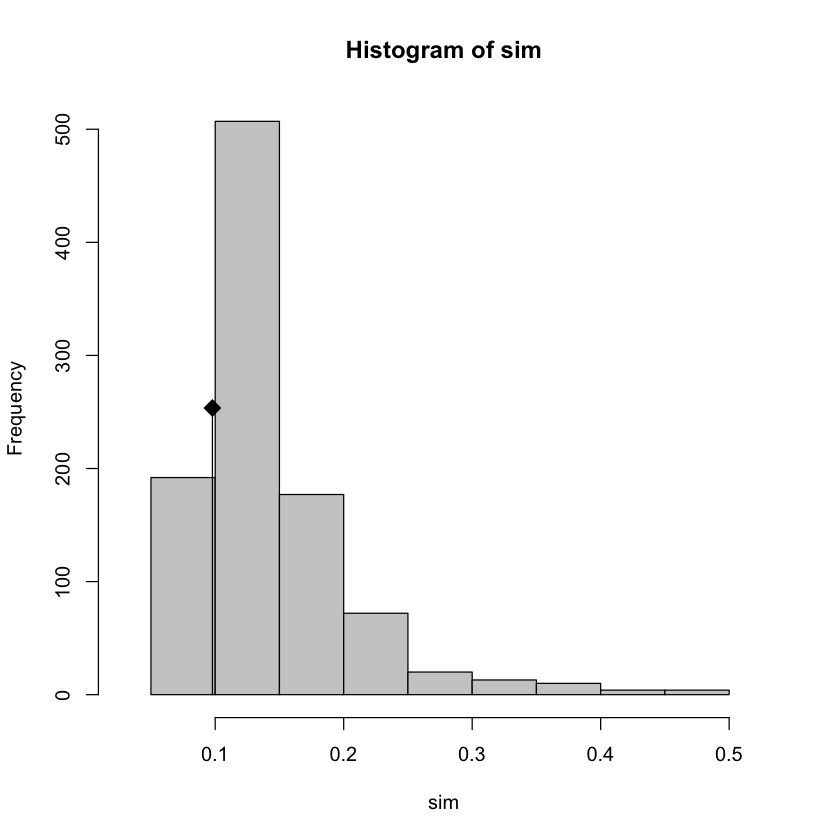

In [192]:
## permutation test (RV coefficient significance):
rv_test <- RV.rtest(dudi1$tab, dudi2$tab, nrepet = 999)
print(rv_test) ## returns RV coeff & p-value
plot(rv_test)

In [193]:
png("../plots/coinertia_summary_IGT.png", width = 3400, height = 2600, res = 400)
s.arrow(coin1$l1, clab = 0.7)
s.arrow(coin1$c1, clab = 0.7)
par(mfrow = c(1,2))
s.corcircle(coin1$aX)
s.corcircle(coin1$aY)
par(mfrow = c(1,1))
plot(coin1)
dev.off()

agg_record_171b10b899eb 
                      2

In [194]:
## scores for each substance on coinertia axes:
scores_beh  <- coin1$lX ## behavioral scores
scores_chem <- coin1$lY ## chemical scores

In [195]:
png("../plots/sub_viz_coinertia_CHEM_IGT.png", width = 3400, height = 2600, res = 400)
plot(scores_chem[,1], scores_chem[,2], 
     col = df_clusters_md$y, pch = 16,
     xlab = "Coinertia axis 1", ylab = "Coinertia axis 2",
     main = "Chemical scores coloured by cluster",
     xlim = c(-25, 25),
     ylim = c(-25, 25))
text(scores_chem[,1], scores_chem[,2], 
     labels = rownames(df_clusters_md), cex = 0.4, pos = 3)
dev.off()

agg_record_171b4122ed25 
                      2

In [196]:
png("../plots/sub_viz_coinertia_BEH_IGT.png", width = 3400, height = 2600, res = 400)
plot(scores_beh[,1], scores_beh[,2], 
     col = df_clusters_beh$y, pch = 16,
     xlab = "Coinertia axis 1", ylab = "Coinertia axis 2",
     main = "Behavioural scores coloured by cluster",
     xlim = c(-25, 25),
     ylim = c(-25, 25))
text(scores_beh[,1], scores_beh[,2], 
     labels = rownames(df_clusters_beh), cex = 0.4, pos = 3)
dev.off()

agg_record_171b7de1991a 
                      2

In [197]:
## top behavioral loadings on axis 1:
sort(abs(coin1$c1[,1]), decreasing = TRUE)[1:5]

## top chemical loadings on axis 1:
sort(abs(coin1$l1[,1]), decreasing = TRUE)[1:5]

[1] 0.3572053 0.3545131 0.3441589 0.3419303 0.3095707

[1] 0.2627505 0.2351486 0.2306243 0.2301948 0.2291924

In [198]:
## plot both behavioral and chemical scores on same axes, with scaled scores -- NO COLOURING:
lX_scaled <- scale(coin1$lX)
lY_scaled <- scale(coin1$lY)

png("../plots/links_plot_IGT_RAW.png", width = 3400, height = 2600, res = 400)
plot(lX_scaled[,1], lX_scaled[,2],
     pch = 16, cex = 0.8,
     xlim = range(c(lX_scaled[,1], lY_scaled[,1])),
     ylim = range(c(lX_scaled[,2], lY_scaled[,2])),
     xlab = "Co-inertie axe 1", ylab = "Co-inertie axe 2",
     main = "Co-inertie — comportement (cercles) vs nature chimique (triangles)")
points(lY_scaled[,1], lY_scaled[,2], 
       pch = 17, cex = 0.8)
arrows(lX_scaled[,1], lX_scaled[,2],
       lY_scaled[,1], lY_scaled[,2],
       length = 0.07, col = "grey")
text(lY_scaled[,1], lY_scaled[,2],
     labels = rownames(df_clusters_beh), cex = 0.4, pos = 3)
dev.off()

agg_record_171b59eea419 
                      2

In [199]:
## plot both behavioral and chemical scores on same axes, with scaled scores -- CHEMICAL CLUSTERS COLOURING:
png("../plots/links_plot_IGT_CHEM_COL.png", width = 3400, height = 2600, res = 400)
plot(lX_scaled[,1], lX_scaled[,2],
     pch = 16, cex = 0.8,
     xlim = range(c(lX_scaled[,1], lY_scaled[,1])),
     ylim = range(c(lX_scaled[,2], lY_scaled[,2])),
     xlab = "Co-inertie axe 1", ylab = "Co-inertie axe 2",
     main = "Co-inertie — comportement (cercles) vs nature chimique (triangles)", col = df_clusters_md$y)
points(lY_scaled[,1], lY_scaled[,2], 
       pch = 17, cex = 0.8, col = df_clusters_md$y)
arrows(lX_scaled[,1], lX_scaled[,2],
       lY_scaled[,1], lY_scaled[,2],
       length = 0.07, col = "grey")
legend("topright", 
       legend = paste("Classe", sort(unique(df_clusters_md$y))),
       col = sort(unique(df_clusters_md$y)),
       pch = 16,
       title = "Classe moléculaire",
       cex = 0.7)
text(lY_scaled[,1], lY_scaled[,2],
     labels = rownames(df_clusters_md), cex = 0.4, pos = 3)
dev.off()

agg_record_171b49c46e75 
                      2

In [200]:
## plot both behavioral and chemical scores on same axes, with scaled scores -- BEHAVIOURAL CLUSTERS COLOURING:
png("../plots/links_plot_IGT_BEH_COL.png", width = 3400, height = 2600, res = 400)
plot(lX_scaled[,1], lX_scaled[,2],
     pch = 16, cex = 0.8,
     xlim = range(c(lX_scaled[,1], lY_scaled[,1])),
     ylim = range(c(lX_scaled[,2], lY_scaled[,2])),
     xlab = "Co-inertie axe 1", ylab = "Co-inertie axe 2",
     main = "Co-inertie — comportement (cercles) vs nature chimique (triangles)", col = df_clusters_beh$y)
points(lY_scaled[,1], lY_scaled[,2], 
       pch = 17, cex = 0.8, col = df_clusters_beh$y)
arrows(lX_scaled[,1], lX_scaled[,2],
       lY_scaled[,1], lY_scaled[,2],
       length = 0.07, col = "grey")
legend("topright", 
       legend = paste("Classe", sort(unique(df_clusters_beh$y))),
       col = sort(unique(df_clusters_beh$y)),
       pch = 16,
       title = "Classe comportementale",
       cex = 0.7)
text(lY_scaled[,1], lY_scaled[,2],
     labels = rownames(df_clusters_beh), cex = 0.4, pos = 3)
dev.off()

agg_record_171bbf5f406 
                     2